# Modes of a Ring Resonator

In Tutorial/Basics/Modes of a Ring Resonator, the modes of a ring resonator were computed by performing a 2d simulation. This example involves simulating the same structure while exploiting the fact that the system has continuous rotational symmetry, by performing the simulation in cylindrical coordinates. 

As always, the starting point is to import the meep and other library modules:

In [26]:
import meep as mp
import argparse
import matplotlib.pyplot as plt
import numpy as np



The parameters of the problem are defined with exactly the same values as in the 2d simulation:

In [18]:
n = 3.4     # index of waveguide
w = 1       # width of waveguide
r = 1       # inner radius of ring
pad = 4     # padding between waveguide and edge of PML
dpml = 2    # thickness of PML

The dimensions and size of the computational cell are defined:

In [19]:
sr = r + w + pad + dpml         # radial size (cell is from 0 to sr)
dimensions = mp.CYLINDRICAL
cell = mp.Vector3(sr, 0, 0)

The key thing is to set the dimensions parameter to **CYLINDRICAL**. This means that all vectors represent (r
,ϕ
,z
) coordinates instead of (x
,y
,z
). The computational cell in the r
 direction is of size **sr = r + w + pad + dpml**, and runs from 0 to sr (by default) rather than from **-sr/2** to **sr/2** as it would for any other dimension. Note that the z
 size is 0 because it is in 2d. The ϕ
 size is also 0, corresponding to the continuous rotational symmetry. A finite ϕ
 size might correspond to discrete rotational symmetry, but this is not currently supported.

In particular, in systems with continuous rotational symmetry, by an analogue of Bloch's theorem, the angular dependence of the fields can always be chosen in the form exp(imϕ)
 for some integer m
. Meep uses this fact to treat the angular dependence analytically, with m
 given by the input variable m which is set to a command-line argument that is 3 by default.

The geometry is now specified by a single **Block** object — remember that this is a block in cylindrical coordinates, so that it really specifies an annular ring:

In [30]:
geometry = [mp.Block(center=mp.Vector3(r + (w / 2)),
                     size=mp.Vector3(w, 1e20, 1e20),
                     material=mp.metal)]

pml_layers = [mp.PML(dpml)]
resolution = 20

PMLs are on "all" sides. The z
 direction has no thickness and therefore it is automatically periodic with no PML. PML is also omitted from the boundary at r
=0 which is handled by the analytical reflection symmetry.

The remaining inputs are almost exactly the same as in the previous 2d simulation. A single Gaussian point source is added in the z
 direction to excite Ez
-polarized modes, with some center frequency and width:

In [31]:
fcen    = 0.15  # pulse center frequency
df      = 0.1   # pulse width (in frequency)
m       = 3     # phi (angular) dependence of the fields given by exp(i m phi)

sources = [mp.Source(src=mp.GaussianSource(fcen, fwidth=df),
                     component=mp.Ez,
                     center=mp.Vector3(r + 0.1))]

Note that this isn't really a point source, however, because of the **cylindrical symmetry**—it is really a **ring source** with a $\phi$ dependence of $\exp(im\phi)$.

Finally, as before, the fields are time-stepped until the source has turned off, plus 200 additional time units. During this time, `Harminv` is used to analyze the $E_z$ field at a given point to extract the **frequencies and decay rates** of the modes.

In [32]:
sim = mp.Simulation(cell_size=cell,
                    geometry=geometry,
                    boundary_layers=pml_layers,
                    resolution=resolution,
                    sources=sources,
                    dimensions=dimensions,
                    m=m)

show the setup geometry

In [33]:
def plot_ring_schematic(r, w, sr, height=1):
    """
    Plot both a 2D polar (top-down) and longitudinal cross-section view
    of the ring resonator.
    
    r      : inner radius of ring
    w      : width of the ring
    sr     : outer boundary of computational cell
    height : arbitrary vertical thickness for schematic
    """
    fig, axs = plt.subplots(1, 2, figsize=(12, 5))

    # --- Polar (top-down) view ---
    theta = np.linspace(0, 2*np.pi, 500)
    axs[0] = plt.subplot(1, 2, 1, projection='polar')
    axs[0].set_theta_zero_location("N")
    axs[0].set_theta_direction(-1)
    axs[0].fill_between(theta, r, r + w, color='skyblue', alpha=0.7, label='Ring waveguide')
    axs[0].plot(theta, sr*np.ones_like(theta), 'k--', label='Computational boundary')
    axs[0].set_rmax(sr + 1)
    axs[0].set_rticks([0, r, r + w, sr])
    axs[0].set_rlabel_position(-22.5)
    axs[0].set_title("Top-down (polar) view")
    axs[0].legend(loc='upper right')

    # --- Longitudinal (cross-section) view ---
    axs[1].set_aspect('equal')
    axs[1].set_xlim(0, sr + 5)
    axs[1].set_ylim(0, height + 0.5)
    axs[1].add_patch(plt.Rectangle((r, 0), w, height, color='skyblue', alpha=0.7))
    axs[1].axvline(sr, color='k', linestyle='--', label='Computational boundary')
    axs[1].set_xlabel("Radius r")
    axs[1].set_ylabel("Height z")
    axs[1].set_title("Longitudinal cross-section")
    axs[1].legend()

    plt.tight_layout()
    plt.show()

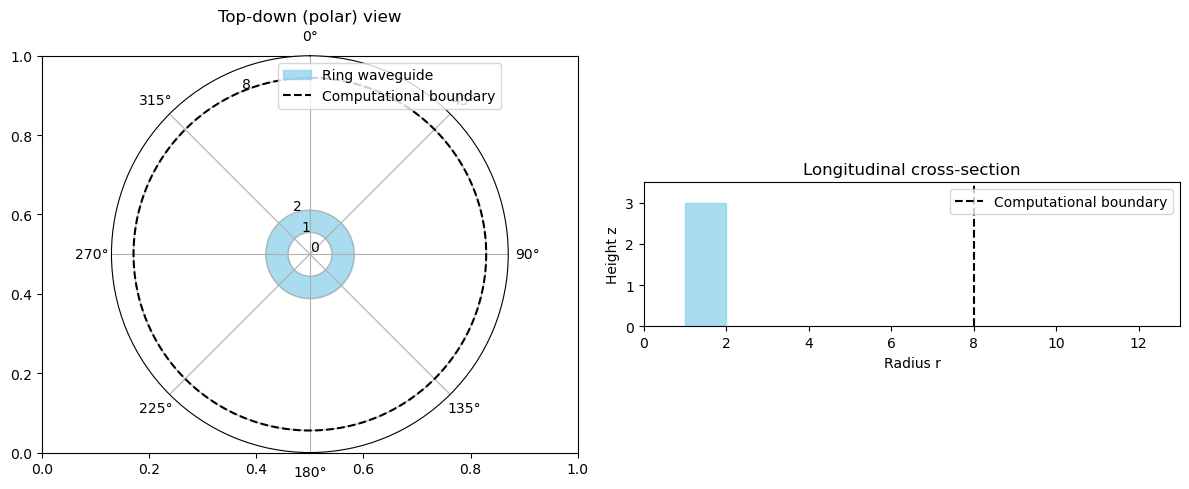

In [28]:
# Plot schematic views before simulation
plot_ring_schematic(r, w, sr, height=3)

### Run simulation

In [34]:
sim.run(mp.after_sources(mp.Harminv(mp.Ez, mp.Vector3(r + 0.1), fcen, df)),
        until_after_sources=200)

-----------
Initializing structure...
time for choose_chunkdivision = 4.00543e-05 s
Working in Cylindrical dimensions.
Computational cell is 8 x 0 x 0.05 with resolution 20
     block, center = (1.5,0,0)
          size (1,1e+20,1e+20)
          axes (1,0,0), (0,1,0), (0,0,1)
          dielectric constant epsilon diagonal = (-1e+20,-1e+20,-1e+20)
time for set_epsilon = 0.00030303 s
-----------
Meep: using complex fields.


FloatProgress(value=0.0, description='0% done ', max=300.0)

harminv0:, frequency, imag. freq., Q, |amp|, amplitude, error
run 0 finished at t = 300.0 (12000 timesteps)


At the very end, one period of the fields is output to create an animation. A single field output would be a 1D dataset along the **$r$** direction, so to make things more interesting `to_appended` is used to append these datasets to a single HDF5 file to obtain an **$r \times t$** 2D dataset.

Also, `in_volume` is used to specify a larger output volume than just the computational cell: in particular, the output is from **$-s_r$ to $s_r$** in the **$r$** direction, where the **$-r$** field values are automatically inferred from the reflection symmetry.

In [15]:
sim.run(mp.in_volume(mp.Volume(center=mp.Vector3(), size=mp.Vector3(2 * sr)),
                     mp.at_beginning(mp.output_epsilon),
                     mp.to_appended("ez", mp.at_every(1 / fcen / 20, mp.output_efield_z))),
        until=1 / fcen)

FloatProgress(value=300.0, description='0% done ', max=306.6666666666667, min=300.0)

creating output file "./eps-000300.00.h5"...
creating output file "./ez.h5"...
on time step 6000 (time=300), 0.037518 s/step
run 1 finished at t = 306.7 (6134 timesteps)


visualization

In [16]:
import h5py
import numpy as np
import matplotlib.pyplot as plt
import os
import sys
import glob

def h5_to_png(data_file, eps_file, output_filename="ez_rt_plot.png", scale=2):
    """
    Replicates the functionality of Meep's h5topng to create a PNG image
    from HDF5 data files.

    Args:
        data_file (str): Path to the HDF5 file containing the field data (e.g., ez.h5).
        eps_file (str): Path to the HDF5 file containing the epsilon data for contours.
        output_filename (str): Name of the output PNG file.
        scale (float): Scaling factor for the output image resolution.
    """
    print(f"--- Reading data from '{os.path.basename(data_file)}' ---")
    print(f"--- Reading geometry from '{os.path.basename(eps_file)}' ---")

    try:
        # --- 1. Read Field and Geometry Data ---
        with h5py.File(data_file, 'r') as f:
            # The dataset is named 'ez' inside the file
            field_data = f['ez'][:]  # This will be an (r, t) array

        with h5py.File(eps_file, 'r') as f:
            eps_data = f['epsilon'][:]
            # The coordinates are stored as an attribute
            r_coords = f['epsilon'].attrs['x']
    except (FileNotFoundError, KeyError, OSError) as e:
        print(f"Error: Could not read HDF5 files. Details: {e}")
        return

    # The time steps are not explicitly saved, so we create a time axis
    num_time_steps = field_data.shape[1]
    time_coords = np.arange(num_time_steps)

    # --- 2. Set up the Plot ---
    # Use figsize and dpi to control the output image size (replicates -S flag)
    fig, ax = plt.subplots(figsize=(5 * scale, 4 * scale), dpi=100)

    # --- 3. Plot the Field Data ---
    # Determine the absolute maximum for a symmetric colormap (replicates -Zc)
    max_abs_val = np.max(np.abs(field_data))
    
    # Use pcolormesh for a 2D plot. Transpose data to have time on the x-axis.
    # Use the 'RdBu' colormap, which is similar to 'dkbluered'.
    im = ax.pcolormesh(
        time_coords,
        r_coords,
        field_data,
        cmap='RdBu',
        vmin=-max_abs_val,
        vmax=max_abs_val,
        shading='gouraud'
    )

    # --- 4. Overlay Geometry Contours ---
    # The epsilon data is 1D, so we create a 2D grid for the contour plot
    # where the epsilon value is constant along the time axis.
    eps_grid_2d, _ = np.meshgrid(eps_data, time_coords, indexing='ij')
    
    # Draw contour lines where the dielectric constant changes
    ax.contour(
        time_coords,
        r_coords,
        eps_grid_2d,
        levels=np.unique(eps_data), # Draw lines at each unique epsilon value
        colors='k',      # Black contours
        linewidths=1.0,
        linestyles='--'
    )

    # --- 5. Formatting and Saving ---
    ax.set_title("Ez Field vs. Radius and Time")
    ax.set_xlabel("Time Step")
    ax.set_ylabel("Radius (r)")
    
    cbar = fig.colorbar(im)
    cbar.set_label("Electric Field (Ez)")
    
    plt.tight_layout()
    plt.savefig(output_filename)
    print(f"--- Successfully saved plot to '{output_filename}' ---")
    plt.close(fig)

#### Use h5_to_png

In [17]:
output_dir = f"output2"

data_filepath = os.path.join(output_dir, f"ez.h5")
    
# Find the epsilon file using a wildcard, as its name includes a timestamp
eps_files = glob.glob(os.path.join(output_dir, f"eps-*.h5"))
    
if not os.path.exists(data_filepath) or not eps_files:
    print("Error: HDF5 files not found. Please run the simulation script first.")
else:
    eps_filepath = eps_files[0]
    output_image_path = os.path.join(output_dir, "ez_rt_plot.png")
        
    # Call the function to generate the plot
    h5_to_png(data_filepath, eps_filepath, output_image_path, scale=2)

--- Reading data from 'ez.h5' ---
--- Reading geometry from 'eps-000300.00.h5' ---
Error: Could not read HDF5 files. Details: "Unable to synchronously open object (object 'ez' doesn't exist)"
